# Modelling Notebook
## European Housing Price Forecasting — EU-26 Panel

**Course:** Machine Learning and Deep Learning, CBS Spring 2026

**Structure of this notebook:**
The analysis is structured into four modelling phases, reported below:

| Phase | Models | Data |
|---|---|---|
| 1 Benchmarks | Naive persistence, Rolling mean, OLS | Pooled (all countries) |
| 2 ML models | Ridge, Lasso, Random Forest, Gradient Boosting | Pooled (all countries) |
| 3 K-Means stratified | Same ML models as Phase 2 | Within each K-Means cluster |
| 4 Literature stratified | Same ML models as Phase 2 | Within literature-based clusters |

### Key design decisions from EDA and clustering
The modelling was conducted based on prior EDA and clustering results:

- **Train/test split:** A strict temporal split is applied: all observations with `year < 2022` are used for training (1,340 rows), while `year ≥ 2022` form the test set (364 rows). This ensures that model evaluation reflects true out-of-sample forecasting, particularly across the post-2022 structural break.

- **Validation:** Hyperparameter tuning was conducted using walk-forward (expanding-window) cross-validation within the training set only. This preserves the time-series structure and prevents look-ahead bias.

- **Feature specification:** The feature set includes lagged macroeconomic variables and structural indicators identified during EDA. The variable `lt_interest_rate` is used as a consistent proxy for long-term financing conditions across all countries.

- **Outlier strategy:** No observations were removed. Extreme values are retained as they correspond to economically meaningful events (e.g. the 2022 interest rate shock).

- **Clustering:** Two approaches are evaluated: K-Means (four clusters based on macro-financial similarity) and literature-based grouping (West/North/South/East).

- Additionally, a density-based approach (DBSCAN) resulted in a single cluster; this is therefore reported as a finding but not used for modelling.

### Output
The primary output of this notebook is `predictions.csv`, which contains all model predictions aligned by `country_code`, `quarter`, and `y_true`.
This file is used as input to `metrics.ipynb`, where all model evaluation and comparison metrics are computed.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import time

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#e8e8e8', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'axes.titlesize': 12, 'axes.labelsize': 10,
})
ACCENT = '#2E5496'
RED    = '#C0392B'
GREEN  = '#1A7A4A'

# Load data: we are taking in this the file created after the previous operations of clustering
candidate_paths = [
    Path('model_data_clustered.xlsx'),
    Path('./model_data_clustered.xlsx'),
    #Path(r'C:\Users\carla\CBS\ml-final-project\s3-clustering\model_data_clustered.xlsx'),
    Path(r'C:\Users\Giulia\Documents\GitHub\european-house-market-forecasting\model_data_clustered.xlsx'),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        'Could not find model_data_clustered.xlsx. Put it in the same folder as this notebook '
        'or update candidate_paths in the data-loading cell.'
    )

df = pd.read_excel(data_path)
df = df.sort_values(['country_code','quarter']).reset_index(drop=True)

print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Data file: {data_path.resolve()}')
print(f'Clusters present: cluster_data={df["cluster_data"].nunique()}, '
      f'cluster_literature={df["cluster_literature"].nunique()}')
print(f'Quarter range: {df["quarter"].min()} -> {df["quarter"].max()}')
print(f'Target (mean/std): {df["target_hpi_next_q"].mean():.3f} / {df["target_hpi_next_q"].std():.3f}')


Loaded: 1704 rows x 42 columns
Data file: C:\Users\Giulia\Documents\GitHub\european-house-market-forecasting\model_data_clustered.xlsx
Clusters present: cluster_data=4, cluster_literature=4
Quarter range: 2005-Q3 -> 2025-Q2
Target (mean/std): 1.035 / 2.222


## 1. Feature Set and Train/Test Split

### Feature set rationale

We use the full lag feature set defined in the EDA pre-modelling phase checklist. `lt_interest_rate` serves as the universal interest rate proxy (covers 26 countries). `mortgage_rate_pct` is excluded from the pooled feature set due to 33% of missing values. This decision was kept constant across all phases for comparability; within individual clusters the coverage may be higher, but adding it only to cluster-specific models would make comparison harder to interpret.  `parliament_rile` is included as it shows strong loading on PC2 in the clustering analysis, confirming it carries structural information.

### Walk-forward cross-validation

Because this is a time series panel, we cannot use random k-fold CV because that would leak future information into the past. We use walk-forward (expanding window) CV implemented via `TimeSeriesSplit`. Each fold expands the training window by one step and validates on the next period. This respects temporal ordering and simulates realistic forecasting conditions.

```
|Train fold 1 |  Val fold 1  |
|Train fold 2 |  Val fold 2  |
|Train fold 3 |  Val fold 3  |
| TEST (year >= 2022) |
```

The test set is never touched during training or CV; it is only used for final evaluation in `metrics.ipynb`.


In [2]:
# Feature columns
FEATURES=[
    # Autoregressive HPI lags (strongest signal from EDA: r=0.30-0.34)
    'hpi_qoq_pct_lag1', 'hpi_qoq_pct_lag2',
    # Macroeconomic lags
    'gdp_qoq_pct_lag1', 'gdp_qoq_pct_lag2',
    'hicp_qoq_pct_lag1', 'hicp_qoq_pct_lag2',
    'unemployment_rate_lag1', 'unemployment_rate_lag2',
    'unemployment_qoq_change',
    # Supply side
    'permits_qoq_pct_lag1', 'permits_qoq_pct_lag2',
    # Interest rates (strongest predictor group from EDA: r=0.30-0.32)
    'lt_interest_rate', 'lt_interest_rate_lag1', 'lt_interest_rate_lag2',
    # Institutional
    'eurozone_member_timevarying',
    'parliament_rile', 'parliament_rile_lag1',
]

# Keep only features that actually exist in the dataframe
FEATURES = [f for f in FEATURES if f in df.columns]
TARGET   = 'target_hpi_next_q'

print(f'Features used ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  {f}')

# Train / test split at 2022 (agreed in EDA Section 8) 
SPLIT_YEAR = 2022
train_df = df[df['year'] < SPLIT_YEAR].dropna(subset=FEATURES + [TARGET]).copy()
test_df  = df[df['year'] >= SPLIT_YEAR].dropna(subset=FEATURES + [TARGET]).copy()

# Sort once here so every later model uses the exact same row order
train_df = train_df.sort_values(['quarter', 'country_code']).reset_index(drop=True)
test_df  = test_df.sort_values(['quarter', 'country_code']).reset_index(drop=True)

print()
print(f'Train rows: {train_df.shape[0]}')
print(f'Test rows:  {test_df.shape[0]}')
print(f'Train quarter range: {train_df["quarter"].min()} -> {train_df["quarter"].max()}')
print(f'Test quarter range:  {test_df["quarter"].min()} -> {test_df["quarter"].max()}')


Features used (17):
  hpi_qoq_pct_lag1
  hpi_qoq_pct_lag2
  gdp_qoq_pct_lag1
  gdp_qoq_pct_lag2
  hicp_qoq_pct_lag1
  hicp_qoq_pct_lag2
  unemployment_rate_lag1
  unemployment_rate_lag2
  unemployment_qoq_change
  permits_qoq_pct_lag1
  permits_qoq_pct_lag2
  lt_interest_rate
  lt_interest_rate_lag1
  lt_interest_rate_lag2
  eurozone_member_timevarying
  parliament_rile
  parliament_rile_lag1

Train rows: 1199
Test rows:  364
Train quarter range: 2006-Q4 -> 2021-Q4
Test quarter range:  2022-Q1 -> 2025-Q2


In [3]:
#Initialise predictions dataframe
# All model predictions will be stored here, aligned by index.
# At the end we save this as predictions.csv for metrics.ipynb.
preds = test_df[['country_code','country','quarter','year',
                  'cluster_data','cluster_literature', TARGET]].copy()
preds = preds.rename(columns={TARGET: 'y_true'})

print('Predictions container initialised:')
print(preds.shape)
print(preds.head(3))


Predictions container initialised:
(364, 7)
  country_code   country  quarter  year  cluster_data cluster_literature  \
0           AT   Austria  2022-Q1  2022             2               West   
1           BE   Belgium  2022-Q1  2022             2               West   
2           BG  Bulgaria  2022-Q1  2022             3               East   

     y_true  
0  2.915629  
1  1.661283  
2  3.113463  


## 2. Helper Functions
We define reusable functions for model training and evaluation. This ensures that identical procedures are applied across pooled, K-Means stratified, and literature-based models. This improves consistency and reduces the risk of implementation discrepancies between model groups


In [4]:
# Expanding window time series cross-validation
def walk_forward_cv(model, X_train, y_train, n_splits=5):
    '''
    Evaluate a model using walk-forward (expanding window) cross-validation.
    Returns mean RMSE across folds.
    n_splits=5 means 5 expanding windows within the training set.
    '''
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_rmses = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_val)
        rmse  = np.sqrt(mean_squared_error(y_val, y_hat))
        fold_rmses.append(rmse)
    return np.mean(fold_rmses), np.std(fold_rmses)

# Train on full training set and predict on test set
def train_and_predict(model, train_sub, test_sub, features=FEATURES):
    '''
    Fit model on train_sub, predict on test_sub.
    Returns array of predictions aligned to test_sub index.
    For sub-datasets (cluster-stratified), test_sub may be smaller.
    '''
    X_tr = train_sub[features].values
    y_tr = train_sub[TARGET].values
    X_te = test_sub[features].values
    model.fit(X_tr, y_tr)
    return model.predict(X_te)

# We printed some metrics to evaluate
def print_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<35} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')
    return rmse, mae, r2

print('Helper functions defined.')
print('  walk_forward_cv(): expanding window CV, returns mean+std RMSE')
print('  train_and_predict(): fit on train, return test predictions')
print('  print_metrics(): RMSE / MAE / R2 for any prediction array')


Helper functions defined.
  walk_forward_cv(): expanding window CV, returns mean+std RMSE
  train_and_predict(): fit on train, return test predictions
  print_metrics(): RMSE / MAE / R2 for any prediction array


## Phase 1: Benchmark Models (Pooled)

In this phase we established the baseline performance using simple and interpretable models. These benchmarks define a minimum performance threshold: any more complex model must outperfom them to be considered informative.

**Benchmarks models:** 3 benchmark specifications are implemented: 

**1. Naive persistence**: This model predict that next quarter's growth equals this quarter's growth. Statistically, it is equivalent to a first-order autoregressive process with the coefficient equal to 1. Evene though this is the simplest possible model, it is a strong baseline. Given the strong lag-1 autocorrelation of 0.632 found in EDA Section 7, this is actually a reasonable predictor and will be hard to beat.

**2. Rolling mean (4-quarter average)**: this model predicts next quarter's growth as the average of the previous 4 quarters. This smooths out short-term noise and captures the medium-term trend. The 4-quarter window was chosen because the EDA found significant autocorrelation at lag-4 (0.548), suggesting a seasonal cycle, which is consistent with annual cyclical patterns observed in housing markets.

**3. OLS Linear Regression**: a linear regression model is estimated using the full feature set without regularisation. This provides a baseline for parametric modelling, which allowed us to assess whether more flexible machine learning methods would deliver incremental predictive performance beyond a standard linear specification.

Note: Naive persistence and rolling mean do not require a train/test split since they are rule-based. We compute them directly on the test set using lagged values.


In [5]:
# Benchmark 1: Naive persistence
# Predict y_t+1 = y_t (current quarter's HPI growth)
# hpi_qoq_pct_lag1 in the test set IS the current quarter's growth
# since the target is next quarter, lag1 is the most recent observation
naive_preds = test_df['hpi_qoq_pct_lag1'].values
preds['naive_persistence'] = naive_preds

print('PHASE 1: BENCHMARKS')
print()
rmse_naive, mae_naive, r2_naive = print_metrics(
    'Naive persistence', preds['y_true'], preds['naive_persistence'])


PHASE 1: BENCHMARKS

  Naive persistence                   RMSE=2.6286  MAE=1.9946  R2=-0.4373


In [6]:
# Benchmark 2: Rolling mean (4-quarter window)
df_sorted = df.sort_values(['country_code','quarter']).copy()

df_sorted['rolling_mean_4q'] = (
    df_sorted.groupby('country_code')['hpi_qoq_pct']
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).mean())
)

# Merge onto test set using country_code + quarter as keys
roll_lookup = (df_sorted[['country_code','quarter','rolling_mean_4q']]
               .drop_duplicates(subset=['country_code','quarter']))

test_with_roll = test_df[['country_code','quarter']].merge(
    roll_lookup, on=['country_code','quarter'], how='left')

# Fill any remaining NaN with that country's mean from the training set
country_means = train_df.groupby('country_code')['hpi_qoq_pct'].mean()
test_with_roll['rolling_mean_4q'] = test_with_roll.apply(
    lambda r: country_means.get(r['country_code'], 0)
    if pd.isna(r['rolling_mean_4q']) else r['rolling_mean_4q'], axis=1)

preds['rolling_mean'] = test_with_roll['rolling_mean_4q'].values

rmse_roll, mae_roll, r2_roll = print_metrics(
    'Rolling mean (4q)', preds['y_true'], preds['rolling_mean'])

  Rolling mean (4q)                   RMSE=2.3309  MAE=1.7390  R2=-0.1301


In [7]:
# Benchmark 3: OLS Linear Regression
# Ordinary Least Squares (OLS) standard regression using the full feature set.
# No regularisation is applied, providing a baseline linear specification.
# Although OLS does not require feature scaling, inputs are standardised
# to ensure consistency and comparability with Ridge and Lasso models.

ols_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

X_train_all = train_df[FEATURES].values
y_train_all = train_df[TARGET].values
X_test_all  = test_df[FEATURES].values
y_test_all  = test_df[TARGET].values

# Walk-forward CV score
cv_rmse, cv_std = walk_forward_cv(
    Pipeline([('scaler',StandardScaler()),('model',LinearRegression())]),
    X_train_all, y_train_all
)
print(f'OLS walk-forward CV RMSE: {cv_rmse:.4f} +/- {cv_std:.4f}')

# Train on full train set, predict test
ols_pipeline.fit(X_train_all, y_train_all)
preds['ols'] = ols_pipeline.predict(X_test_all)

rmse_ols, mae_ols, r2_ols = print_metrics(
    'OLS linear regression', preds['y_true'], preds['ols'])

# OLS coefficients: which features matter most?
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': ols_pipeline.named_steps['model'].coef_
}).sort_values('coefficient', key=abs, ascending=False)
print('\nOLS top 10 coefficients (absolute magnitude):')
print(coef_df.head(10).to_string(index=False))

OLS walk-forward CV RMSE: 1.9187 +/- 0.2490
  OLS linear regression               RMSE=2.3665  MAE=1.8194  R2=-0.1649

OLS top 10 coefficients (absolute magnitude):
                    feature  coefficient
           lt_interest_rate    -0.732017
     unemployment_rate_lag1    -0.430962
          hicp_qoq_pct_lag2    -0.379027
           hpi_qoq_pct_lag2     0.296314
      lt_interest_rate_lag1     0.254200
          hicp_qoq_pct_lag1    -0.253425
eurozone_member_timevarying    -0.191521
           hpi_qoq_pct_lag1     0.176225
     unemployment_rate_lag2     0.169036
           gdp_qoq_pct_lag1     0.165415


PHASE 1 SUMMARY

  Naive persistence                   RMSE=2.6286  MAE=1.9946  R2=-0.4373
  Rolling mean (4q)                   RMSE=2.3309  MAE=1.7390  R2=-0.1301
  OLS regression                      RMSE=2.3665  MAE=1.8194  R2=-0.1649


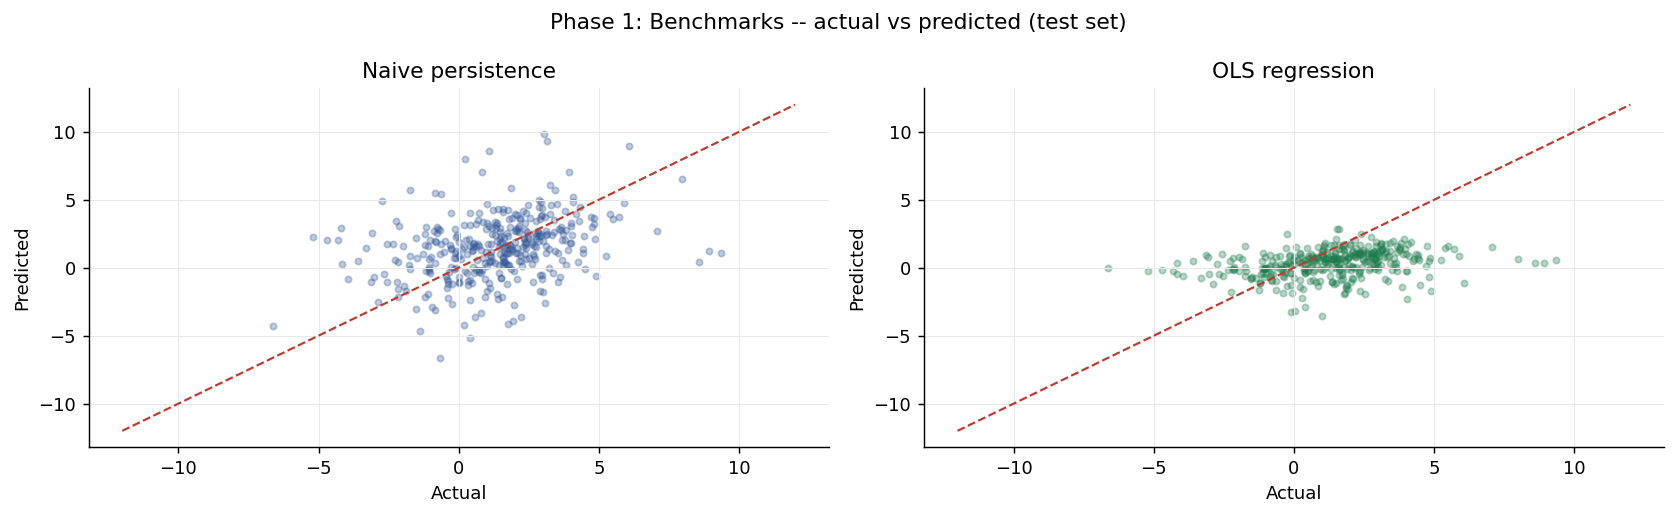

In [8]:
# Phase 1 summary
print('PHASE 1 SUMMARY')
print()
benchmarks = {
    'Naive persistence':  (preds['y_true'], preds['naive_persistence']),
    'Rolling mean (4q)':  (preds['y_true'], preds['rolling_mean']),
    'OLS regression':     (preds['y_true'], preds['ols']),
}
for name, (yt, yp) in benchmarks.items():
    print_metrics(name, yt, yp)

# Visual: actual vs predicted for OLS
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(preds['y_true'], preds['naive_persistence'],
                alpha=0.3, s=12, color=ACCENT)
axes[0].plot([-12,12],[-12,12], color=RED, linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Naive persistence')

axes[1].scatter(preds['y_true'], preds['ols'],
                alpha=0.3, s=12, color=GREEN)
axes[1].plot([-12,12],[-12,12], color=RED, linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('OLS regression')

plt.suptitle('Phase 1: Benchmarks -- actual vs predicted (test set)', fontsize=12)
plt.tight_layout()
plt.show()


Across all benchmarks, the consistently negative R² values suggest that predictive relationships have weakened since 2022. This points to a structural break in the underlying dynamics that is not well captured by simple persistence or linear models. This confirms what actually happened in the EU, because 2022 was a turning point, since it is when interest rates started rising quickly, changing how affordable housing was, and making earlier market patterns less reliable. 

## Phase 2: Machine Learning Models (Pooled)

We now train four machine learning models on the full pooled dataset. Each model is evaluated using walk-forward cross-validation on the training set for hyperparameter tuning, then retrained on the full training set and evaluated on the held-out test set.

**Ridge Regression** applies L2 regularisation to OLS, shrinking coefficients toward zero without eliminating them. This is useful when features are moderately correlated, as EDA shows a correlation of r = 0.665 between `mortgage_rate_pct` and `lt_interest_rate`.

**Lasso Regression** applies L1 regularisation, which can shrink some coefficients exactly to zero, effectively performing feature selection. This is useful if a subset of the 17 features is not informative. 

**Random Forest** constructs an ensemble of decision trees trained on bootstrapped samples and averages their predictions. It captures non-linear relationships and interactions and is robust to outliers. 

**Gradient Boosting** builds trees sequentially, where each tree corrects the errors of the previous ones. It is often a strong baseline model for structured tabular data.

**Hyperparameter tuning:** We use a small predefined grid evaluated via walk-forward cross-validation. The optimal hyperparameters (e.g. alpha for Ridge/Lasso and key tree parameters) are selected based on CV RMSE.

In [9]:
# Phase 2.1: Ridge Regression
from sklearn.linear_model import RidgeCV

print('RIDGE REGRESSION')
# RidgeCV uses efficient leave-one-out CV internally to select alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=alphas, cv=5, scoring='neg_root_mean_squared_error'))
])

# Walk-forward CV
cv_rmse, cv_std = walk_forward_cv(
    Pipeline([('scaler',StandardScaler()),
              ('model',RidgeCV(alphas=alphas))]),
    X_train_all, y_train_all
)
print(f'  Walk-forward CV RMSE: {cv_rmse:.4f} +/- {cv_std:.4f}')

# Train on full train, predict test
ridge_cv.fit(X_train_all, y_train_all)
preds['ridge'] = ridge_cv.predict(X_test_all)
best_alpha = ridge_cv.named_steps['model'].alpha_
print(f'  Best alpha selected: {best_alpha}')

print_metrics('Ridge', preds['y_true'], preds['ridge'])


RIDGE REGRESSION
  Walk-forward CV RMSE: 1.9052 +/- 0.2449
  Best alpha selected: 100.0
  Ridge                               RMSE=2.3104  MAE=1.7749  R2=-0.1104


(np.float64(2.310423275227072), 1.7749467422633476, -0.11035340210549749)

In [10]:
# Phase 2.2: Lasso Regression 
from sklearn.linear_model import LassoCV

print('LASSO REGRESSION')
lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LassoCV(alphas=alphas, cv=TimeSeriesSplit(n_splits=5),
                       max_iter=5000))
])

cv_rmse, cv_std = walk_forward_cv(
    Pipeline([('scaler',StandardScaler()),
              ('model',LassoCV(alphas=alphas, max_iter=5000))]),
    X_train_all, y_train_all
)
print(f'  Walk-forward CV RMSE: {cv_rmse:.4f} +/- {cv_std:.4f}')

lasso_cv.fit(X_train_all, y_train_all)
preds['lasso'] = lasso_cv.predict(X_test_all)
best_alpha_lasso = lasso_cv.named_steps['model'].alpha_
print(f'  Best alpha selected: {best_alpha_lasso}')

# Which features survived (non-zero coefficients)?
lasso_coef = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': lasso_cv.named_steps['model'].coef_
})
kept = lasso_coef[lasso_coef['coefficient'] != 0].sort_values('coefficient', key=abs, ascending=False)
zeroed = lasso_coef[lasso_coef['coefficient'] == 0]['feature'].tolist()
print(f'  Features kept: {len(kept)} / {len(FEATURES)}')
print(f'  Zeroed out: {zeroed}')
print(kept.to_string(index=False))

print_metrics('Lasso', preds['y_true'], preds['lasso'])


LASSO REGRESSION
  Walk-forward CV RMSE: 1.8980 +/- 0.2426
  Best alpha selected: 0.01
  Features kept: 14 / 17
  Zeroed out: ['unemployment_rate_lag2', 'lt_interest_rate_lag1', 'lt_interest_rate_lag2']
                    feature  coefficient
           lt_interest_rate    -0.509101
          hicp_qoq_pct_lag2    -0.368363
           hpi_qoq_pct_lag2     0.296768
     unemployment_rate_lag1    -0.245606
          hicp_qoq_pct_lag1    -0.238174
eurozone_member_timevarying    -0.187177
           hpi_qoq_pct_lag1     0.172667
           gdp_qoq_pct_lag1     0.156694
           gdp_qoq_pct_lag2     0.147788
            parliament_rile     0.121556
       permits_qoq_pct_lag2     0.102051
    unemployment_qoq_change    -0.101190
       parliament_rile_lag1     0.046510
       permits_qoq_pct_lag1     0.031253
  Lasso                               RMSE=2.3421  MAE=1.7989  R2=-0.1410


(np.float64(2.3420966100358673), 1.7988869730431247, -0.14100549656184036)

RANDOM FOREST
  Walk-forward CV grid search:
    {'n_estimators': 200, 'max_depth': 4, 'min_samples_leaf': 5}  CV RMSE=1.9020 +/- 0.2405 <-- best
    {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 5}  CV RMSE=1.8843 +/- 0.2392 <-- best
    {'n_estimators': 300, 'max_depth': 6, 'min_samples_leaf': 3}  CV RMSE=1.8772 +/- 0.2408 <-- best
    {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 5}  CV RMSE=1.8797 +/- 0.2469

  Best params: {'n_estimators': 300, 'max_depth': 6, 'min_samples_leaf': 3}
  Random Forest                       RMSE=2.3548  MAE=1.7704  R2=-0.1535


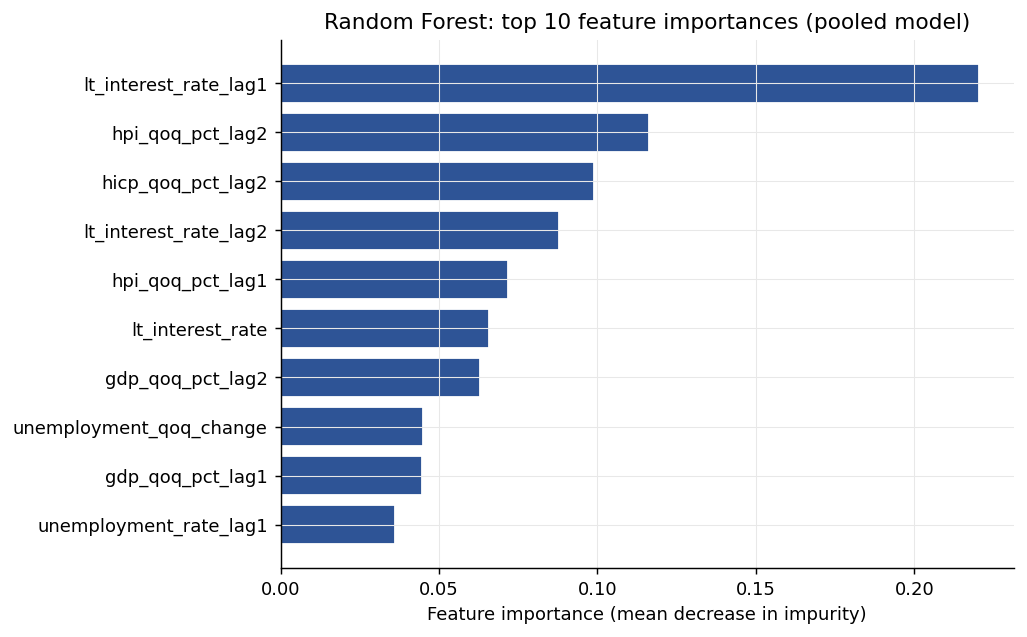

In [ ]:
# Phase 2.3: Random Forest
print('RANDOM FOREST')

# Hyperparameter grid evaluated using walk-forward cross-validation.
rf_grid = [
    {'n_estimators':200, 'max_depth':4,    'min_samples_leaf':5},
    {'n_estimators':200, 'max_depth':6,    'min_samples_leaf':5},
    {'n_estimators':300, 'max_depth':6,    'min_samples_leaf':3},
    {'n_estimators':300, 'max_depth':None, 'min_samples_leaf':5},
]

best_rf_rmse   = np.inf
best_rf_params = rf_grid[0]

print('  Walk-forward CV grid search:')
for params in rf_grid:
    rf_candidate = RandomForestRegressor(
        random_state=42, n_jobs=-1, **params)
    cv_rmse, cv_std = walk_forward_cv(rf_candidate, X_train_all, y_train_all)
    marker = ' <-- best' if cv_rmse < best_rf_rmse else ''
    print(f'    {params}  CV RMSE={cv_rmse:.4f} +/- {cv_std:.4f}{marker}')
    if cv_rmse < best_rf_rmse:
        best_rf_rmse   = cv_rmse
        best_rf_params = params

# Train best RF on full training set
rf_best = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
rf_best.fit(X_train_all, y_train_all)
preds['rf'] = rf_best.predict(X_test_all)

print(f'\n  Best params: {best_rf_params}')
print_metrics('Random Forest', preds['y_true'], preds['rf'])

# Feature importance
fi_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi_df['feature'][:10][::-1], fi_df['importance'][:10][::-1],
        color=ACCENT, edgecolor='white')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest: top 10 feature importances (pooled model)')
plt.tight_layout()
plt.show()


In [12]:
# Phase 2.4: Gradient Boosting
print('GRADIENT BOOSTING')

gb_grid = [
    {'n_estimators':200, 'learning_rate':0.05, 'max_depth':3, 'subsample':0.8},
    {'n_estimators':200, 'learning_rate':0.10, 'max_depth':3, 'subsample':0.8},
    {'n_estimators':300, 'learning_rate':0.05, 'max_depth':4, 'subsample':0.8},
    {'n_estimators':300, 'learning_rate':0.05, 'max_depth':3, 'subsample':1.0},
]

best_gb_rmse   = np.inf
best_gb_params = gb_grid[0]

print('  Walk-forward CV grid search:')
for params in gb_grid:
    gb_candidate = GradientBoostingRegressor(random_state=42, **params)
    cv_rmse, cv_std = walk_forward_cv(gb_candidate, X_train_all, y_train_all)
    marker = ' <-- best' if cv_rmse < best_gb_rmse else ''
    print(f'    {params}  CV RMSE={cv_rmse:.4f} +/- {cv_std:.4f}{marker}')
    if cv_rmse < best_gb_rmse:
        best_gb_rmse   = cv_rmse
        best_gb_params = params

gb_best = GradientBoostingRegressor(random_state=42, **best_gb_params)
gb_best.fit(X_train_all, y_train_all)
preds['gb'] = gb_best.predict(X_test_all)

print(f'\n  Best params: {best_gb_params}')
print_metrics('Gradient Boosting', preds['y_true'], preds['gb'])

GRADIENT BOOSTING
  Walk-forward CV grid search:
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8}  CV RMSE=1.9317 +/- 0.2057 <-- best
    {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8}  CV RMSE=1.9901 +/- 0.2310
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8}  CV RMSE=1.9580 +/- 0.2360
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 1.0}  CV RMSE=2.0253 +/- 0.2475

  Best params: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8}
  Gradient Boosting                   RMSE=2.3595  MAE=1.7934  R2=-0.1580


(np.float64(2.359504376715158), 1.7934447933894706, -0.1580297059228426)

PHASE 2 SUMMARY: ALL POOLED MODELS

  Naive persistence         RMSE=2.6286  MAE=1.9946  R2=-0.4373
  Rolling mean              RMSE=2.3309  MAE=1.7390  R2=-0.1301
  OLS                       RMSE=2.3665  MAE=1.8194  R2=-0.1649
  Ridge                     RMSE=2.3104  MAE=1.7749  R2=-0.1104
  Lasso                     RMSE=2.3421  MAE=1.7989  R2=-0.1410
  Random Forest             RMSE=2.3548  MAE=1.7704  R2=-0.1535
  Gradient Boosting         RMSE=2.3595  MAE=1.7934  R2=-0.1580


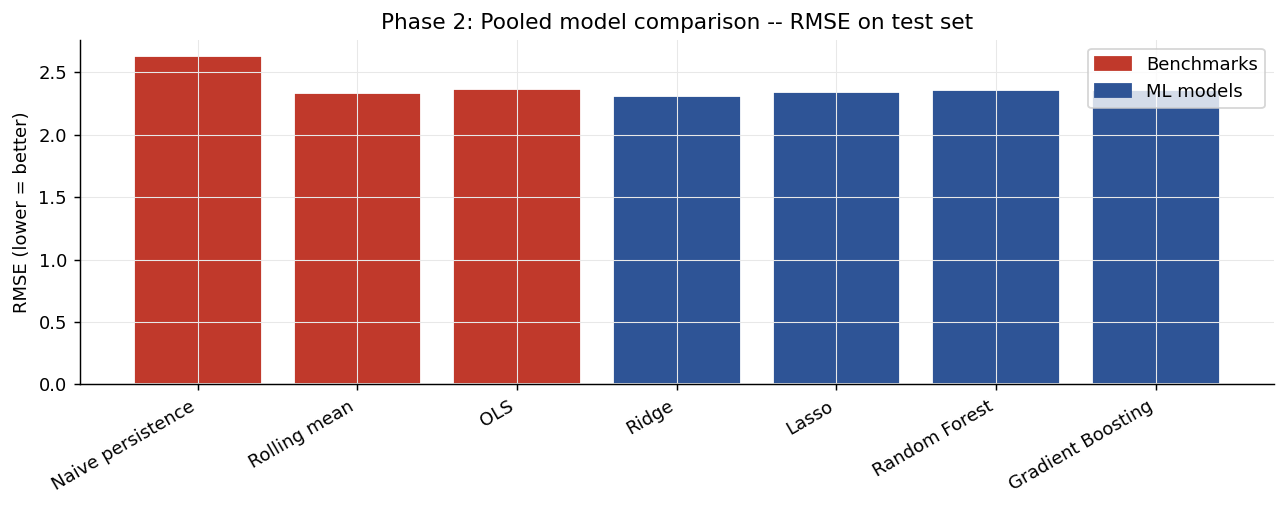

In [13]:
# Phase 2 summary
print('PHASE 2 SUMMARY: ALL POOLED MODELS')
print()
pooled_models = {
    'Naive persistence': 'naive_persistence',
    'Rolling mean':      'rolling_mean',
    'OLS':               'ols',
    'Ridge':             'ridge',
    'Lasso':             'lasso',
    'Random Forest':     'rf',
    'Gradient Boosting': 'gb',
}
results = []
for name, col in pooled_models.items():
    rmse = np.sqrt(mean_squared_error(preds['y_true'], preds[col]))
    mae  = mean_absolute_error(preds['y_true'], preds[col])
    r2   = r2_score(preds['y_true'], preds[col])
    results.append({'model':name,'rmse':rmse,'mae':mae,'r2':r2,'phase':'Pooled'})
    print(f'  {name:<25} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')

# Visual comparison
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(10, 4))
colors = [RED if 'Naive' in m or 'Rolling' in m or 'OLS' in m
          else ACCENT for m in results_df['model']]
ax.bar(results_df['model'], results_df['rmse'], color=colors, edgecolor='white')
ax.set_ylabel('RMSE (lower = better)')
ax.set_title('Phase 2: Pooled model comparison -- RMSE on test set')
ax.set_xticklabels(results_df['model'], rotation=30, ha='right')
red_p   = mpatches.Patch(color=RED,   label='Benchmarks')
blue_p  = mpatches.Patch(color=ACCENT,label='ML models')
ax.legend(handles=[red_p,blue_p])
plt.tight_layout()
plt.show()


TRAINING TIME COMPARISON 

  OLS                       0.003s
  Ridge                     0.006s
  Lasso                     0.012s
  Random Forest             0.540s
  Gradient Boosting         0.797s

Relative training time (OLS = 1.0x):
  OLS                       1.0x
  Ridge                     1.8x
  Lasso                     3.6x
  Random Forest             156.9x
  Gradient Boosting         231.6x


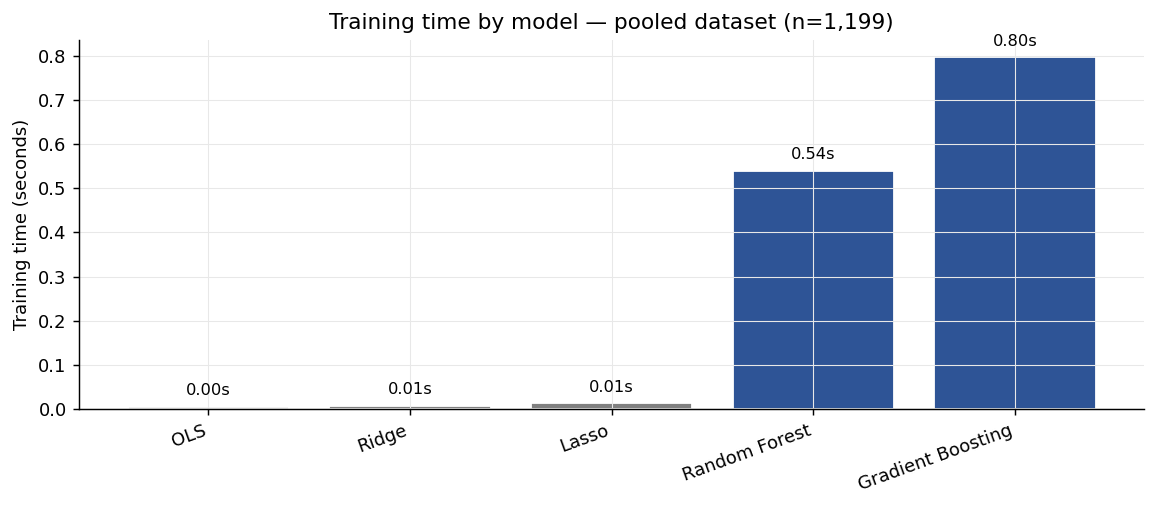

In [14]:
# Running times comparison
#Training time comparison across model types

print('TRAINING TIME COMPARISON ')
print()

timing_models = {
    'OLS':               Pipeline([('scaler', StandardScaler()),
                                   ('model',  LinearRegression())]),
    'Ridge':             Pipeline([('scaler', StandardScaler()),
                                   ('model',  RidgeCV(alphas=[0.01,0.1,1,10,100,1000]))]),
    'Lasso':             Pipeline([('scaler', StandardScaler()),
                                   ('model',  LassoCV(alphas=[0.01,0.1,1,10,100,1000],
                                                      max_iter=5000))]),
    'Random Forest':     RandomForestRegressor(random_state=42, n_jobs=-1,
                                               **best_rf_params),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42,
                                                   **best_gb_params),
}

timing_results = {}
for name, model in timing_models.items():
    start = time.perf_counter()
    model.fit(X_train_all, y_train_all)
    elapsed = time.perf_counter() - start
    timing_results[name] = elapsed
    print(f'  {name:<25} {elapsed:.3f}s')

# Relative to OLS
print()
print('Relative training time (OLS = 1.0x):')
ols_time = timing_results['OLS']
for name, t in timing_results.items():
    ratio = t / ols_time
    print(f'  {name:<25} {ratio:.1f}x')

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors = [ACCENT if n in ['Random Forest','Gradient Boosting']
          else 'gray' for n in timing_results]
bars = ax.bar(timing_results.keys(), timing_results.values(),
              color=colors, edgecolor='white')
ax.set_ylabel('Training time (seconds)')
ax.set_title('Training time by model — pooled dataset (n=1,199)')
ax.set_xticklabels(timing_results.keys(), rotation=20, ha='right')
for bar, val in zip(bars, timing_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val:.2f}s', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Residual Analysis: best pooled model
Residual analysis was performed for the best pooled model which is Ridge regression, as the summary of Phase 2 shows. In forecasting settings, it is also important to assess if errors are systematically structured. We evaluate residuals against fitted values to detect bias or non-random structure, and residuals over time to identify periods of systematic over or under-prediction. 

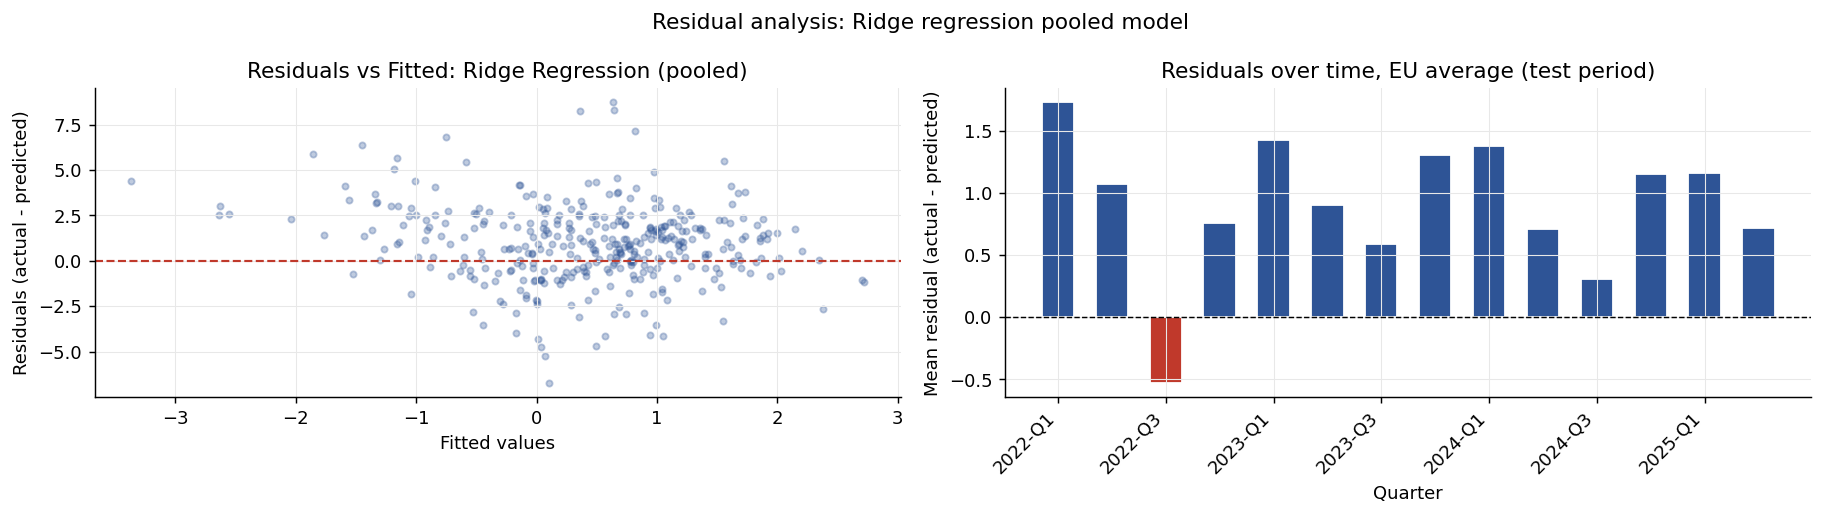

Mean residual: 0.9056  (0 = unbiased)
Std residual:  2.1285
Max under-prediction: -6.7209
Max over-prediction:  8.7259


In [15]:
# Residual analysis: best pooled model (Ridge)
residuals = preds['y_true'] - preds['ridge']
fitted    = preds['ridge']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: Residuals vs fitted
axes[0].scatter(fitted, residuals, alpha=0.3, s=12, color=ACCENT)
axes[0].axhline(0, color=RED, linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals (actual - predicted)')
axes[0].set_title('Residuals vs Fitted: Ridge Regression (pooled)')

# Panel 2: Residuals over time (EU average per quarter)
resid_by_q = preds.copy()
resid_by_q['residual'] = residuals
resid_time = resid_by_q.groupby('quarter')['residual'].mean()

axes[1].bar(
    resid_time.index,
    resid_time.values,
    color=[RED if v < 0 else ACCENT for v in resid_time.values],
    edgecolor='white',
    width=0.6
)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Mean residual (actual - predicted)')
axes[1].set_title('Residuals over time, EU average (test period)')

ticks = resid_time.index[::2]
axes[1].set_xticks(ticks)
axes[1].set_xticklabels(ticks, rotation=45, ha='right')

plt.suptitle('Residual analysis: Ridge regression pooled model', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.4f}  (0 = unbiased)')
print(f'Std residual:  {residuals.std():.4f}')
print(f'Max under-prediction: {residuals.min():.4f}')
print(f'Max over-prediction:  {residuals.max():.4f}')

## Phase 3: K-Means Stratified Models
We repeat the ML pipeline from Phase 2, but models are now trained and evaluated **separately within each K-Means cluster**. The key question is: does a model trained only on countries sharing a cluster outperform the pooled model when evaluated on those same countries?

This may help because the pooled model must find a single set of coefficients across all 26 countries simultaneously. If housing markets in different clusters respond differently to the same macroeconomic inputs, for instance, Eastern markets being more sensitive to GDP growth while Western markets react more to interest rates, then cluster-specific models can capture these heterogeneous relationships.

**Overfitting and underfitting detection:** Before selecting a model, each cluster runs a diagnostic check using Ridge regression as a proxy. It compares training RMSE against walk-forward cross-validation RMSE. If the CV-to-train RMSE ratio exceeds 1.20, the cluster is flagged as overfit; if training RMSE itself exceeds 1.50, it is flagged as underfit.

**Adaptive model selection:** Based on cluster size and the diagnostic result, the pipeline selects one of three model sets:
- Small clusters (< 200 rows) or overfit clusters: Ridge and Lasso only, to avoid memorisation.
- Medium clusters (200–400 rows): Conservative tree parameters with shallow depth and fewer estimators.
- Large clusters (400+ rows): Full tuned Random Forest and Gradient Boosting hyperparameters carried over from Phase 2.

In [24]:
# Phase 3: K-Means stratified models
print('PHASE 3: K-MEANS STRATIFIED MODELS')

OVERFIT_RATIO_THRESHOLD = 1.20
UNDERFIT_TRAIN_RMSE     = 1.50


# OVERFITTING / UNDERFITTING CHECK
def overfitting_check(X_train, y_train, n_splits=5, label=''):

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10))
    ])
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    train_rmse  = np.sqrt(mean_squared_error(y_train, train_preds))

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_rmses = []

    for tr_idx, val_idx in tscv.split(X_train):
        fold_model = Pipeline([
            ('scaler', StandardScaler()),
            ('model',  Ridge(alpha=10))
        ])
        fold_model.fit(X_train[tr_idx], y_train[tr_idx])
        fold_preds = fold_model.predict(X_train[val_idx])
        fold_rmse  = np.sqrt(mean_squared_error(y_train[val_idx], fold_preds))
        fold_rmses.append(fold_rmse)

    cv_rmse = np.mean(fold_rmses)

    ratio       = cv_rmse / train_rmse if train_rmse > 0 else np.nan
    is_overfit  = ratio > OVERFIT_RATIO_THRESHOLD
    is_underfit = train_rmse > UNDERFIT_TRAIN_RMSE

    if is_overfit:    flag = 'OVERFIT'
    elif is_underfit: flag = 'UNDERFIT'
    else:             flag = 'OK'

    print(f'    [{label}] train={train_rmse:.4f} | cv={cv_rmse:.4f} | ratio={ratio:.2f} | {flag}')

    return {
        'train_rmse':  train_rmse,
        'cv_rmse':     cv_rmse,
        'ratio':       ratio,
        'is_overfit':  is_overfit,
        'is_underfit': is_underfit,
        'flag':        flag
    }


# ALL 4 MODELS — same for every cluster
def get_ml_models(n_folds=5):
    return {
        'ridge': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  RidgeCV(alphas=alphas))
        ]),
        'lasso': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  LassoCV(alphas=alphas, max_iter=5000,
                               cv=TimeSeriesSplit(n_splits=n_folds)))
        ]),
        'rf': RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params),
        'gb': GradientBoostingRegressor(random_state=42, **best_gb_params),
    }


# MAIN LOOP
km_clusters = sorted(df['cluster_data'].dropna().unique())
print(f'K-Means clusters: {km_clusters}')
print()

diagnostic_rows = []

for cid in km_clusters:

    cid      = int(cid)
    train_c  = train_df[train_df['cluster_data'] == cid]
    test_c   = test_df[test_df['cluster_data']   == cid]
    test_idx = test_c.index
    n_train  = len(train_c)

    countries = sorted(df[df['cluster_data'] == cid]['country_code'].unique())
    print(f'K-Means Cluster {cid} ({len(countries)} countries: {countries})')
    print(f'    Train: {n_train} rows  |  Test: {len(test_c)} rows')

    if n_train < 30 or len(test_c) < 5:
        print('    SKIPPED -- too few rows for reliable modelling\n')
        continue

    X_tr = train_c[FEATURES].values
    y_tr = train_c[TARGET].values
    X_te = test_c[FEATURES].values

    n_folds = min(5, max(2, n_train // 20))

    # Diagnostic (informational only)
    print(f'    Overfitting/underfitting check (n_folds={n_folds}):')
    diagnostic = overfitting_check(X_tr, y_tr, n_splits=n_folds, label=f'km{cid}')

    diagnostic_rows.append({
        'cluster':    f'km{cid}',
        'n_train':    n_train,
        'train_rmse': round(diagnostic['train_rmse'], 4),
        'cv_rmse':    round(diagnostic['cv_rmse'],    4),
        'ratio':      round(diagnostic['ratio'],      2),
        'flag':       diagnostic['flag']
    })

    # Train, predict, store
    for mname, model in get_ml_models(n_folds=n_folds).items():
        col_name = f'{mname}_km{cid}'
        try:
            model.fit(X_tr, y_tr)
            y_hat = model.predict(X_te)
            preds.loc[test_idx, col_name] = y_hat
            rmse = np.sqrt(mean_squared_error(test_c[TARGET], y_hat))
            print(f'    {mname:<8} RMSE={rmse:.4f}')
        except Exception as e:
            print(f'    {mname:<8} ERROR: {e}')
    print()


# SUMMARY TABLE
diagnostic_df = pd.DataFrame(diagnostic_rows)
print()
print('OVERFITTING / UNDERFITTING SUMMARY')
print()
print(diagnostic_df.to_string(index=False))

PHASE 3: K-MEANS STRATIFIED MODELS
K-Means clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

K-Means Cluster 0 (4 countries: ['ES', 'FI', 'FR', 'IT'])
    Train: 193 rows  |  Test: 56 rows
    Overfitting/underfitting check (n_folds=5):
    [km0] train=1.1354 | cv=1.7452 | ratio=1.54 | OVERFIT
    ridge    RMSE=1.7310
    lasso    RMSE=1.7764
    rf       RMSE=1.6109
    gb       RMSE=1.4946

K-Means Cluster 1 (2 countries: ['IE', 'MT'])
    Train: 100 rows  |  Test: 28 rows
    Overfitting/underfitting check (n_folds=5):
    [km1] train=2.3802 | cv=3.2440 | ratio=1.36 | OVERFIT
    ridge    RMSE=2.5683
    lasso    RMSE=1.3372
    rf       RMSE=1.8275
    gb       RMSE=2.1120

K-Means Cluster 2 (9 countries: ['AT', 'BE', 'CZ', 'DE', 'DK', 'LU', 'NL', 'SE', 'SI'])
    Train: 440 rows  |  Test: 126 rows
    Overfitting/underfitting check (n_folds=5):
    [km2] train=1.4951 | cv=1.6139 | ratio=1.08 | OK
    ridge    RMSE=1.9147
    lasso    RMSE=2.1041
    rf       RMSE=2.1

In [25]:
# Phase 3: Compare cluster-stratified vs pooled RF and GB
print('K-MEANS STRATIFIED vs POOLED: RF and GB comparison')
print()

for mname, pooled_col in [('RF','rf'),('GB','gb')]:
    print(f'{mname}:')
    for cid in km_clusters:
        cid = int(cid)
        strat_col = f'{pooled_col}_km{cid}'
        if strat_col not in preds.columns:
            continue
        mask = preds['cluster_data'] == cid
        if mask.sum() == 0:
            continue
        yt = preds.loc[mask, 'y_true']
        yp_strat  = preds.loc[mask, strat_col]
        yp_pooled = preds.loc[mask, pooled_col]
        rmse_strat  = np.sqrt(mean_squared_error(yt, yp_strat))
        rmse_pooled = np.sqrt(mean_squared_error(yt, yp_pooled))
        diff = rmse_strat - rmse_pooled
        direction = 'BETTER' if diff < 0 else 'worse'
        countries = sorted(df[df['cluster_data']==cid]['country_code'].unique())
        print(f'  Cluster {cid} ({countries})')
        print(f'    Pooled RMSE:     {rmse_pooled:.4f}')
        print(f'    Stratified RMSE: {rmse_strat:.4f}  ({direction}, diff={diff:+.4f})')
    print()


K-MEANS STRATIFIED vs POOLED: RF and GB comparison

RF:
  Cluster 0 (['ES', 'FI', 'FR', 'IT'])
    Pooled RMSE:     1.7344
    Stratified RMSE: 1.6109  (BETTER, diff=-0.1235)
  Cluster 1 (['IE', 'MT'])
    Pooled RMSE:     1.4681
    Stratified RMSE: 1.8275  (worse, diff=+0.3594)
  Cluster 2 (['AT', 'BE', 'CZ', 'DE', 'DK', 'LU', 'NL', 'SE', 'SI'])
    Pooled RMSE:     2.0694
    Stratified RMSE: 2.1211  (worse, diff=+0.0517)
  Cluster 3 (['BG', 'CY', 'EE', 'HR', 'HU', 'LT', 'LV', 'PL', 'PT', 'RO', 'SK'])
    Pooled RMSE:     2.8491
    Stratified RMSE: 2.5048  (BETTER, diff=-0.3443)

GB:
  Cluster 0 (['ES', 'FI', 'FR', 'IT'])
    Pooled RMSE:     1.7663
    Stratified RMSE: 1.4946  (BETTER, diff=-0.2717)
  Cluster 1 (['IE', 'MT'])
    Pooled RMSE:     1.8177
    Stratified RMSE: 2.1120  (worse, diff=+0.2943)
  Cluster 2 (['AT', 'BE', 'CZ', 'DE', 'DK', 'LU', 'NL', 'SE', 'SI'])
    Pooled RMSE:     2.0695
    Stratified RMSE: 2.2630  (worse, diff=+0.1935)
  Cluster 3 (['BG', 'CY', 'EE', 

## Phase 4: Literature-Based Stratified Models

We repeated the same stratified modelling exercise using the literature-based clusters (West, North, South, East) as the primary stratification scheme.

The literature clusters are our preferred stratification for three reasons established in the clustering notebook:
1. More balanced group sizes (East=12, West=6, South=5, North=3 countries)
2. The ANOVA confirmed significant target mean differences across groups (F=7.56, p<0.001)

The North cluster (DK, FI, SE) is the smallest with only 3 countries. We train it but note reduced statistical reliability.

In [27]:
# Phase 4: Literature stratified models
lit_clusters = ['East','West','South','North']
lit_clusters = [g for g in lit_clusters
                if g in df['cluster_literature'].values]
print(f'Literature clusters: {lit_clusters}')
print()

for group in lit_clusters:
    train_g  = train_df[train_df['cluster_literature'] == group]
    test_g   = test_df[test_df['cluster_literature']   == group]
    test_idx = test_g.index

    countries = sorted(df[df['cluster_literature']==group]['country_code'].unique())
    print(f'Literature: {group} ({len(countries)} countries: {countries})')
    print(f'    Train: {len(train_g)} rows  |  Test: {len(test_g)} rows')

    if len(train_g) < 30 or len(test_g) < 5:
        print('    SKIPPED -- too few rows')
        continue

    X_tr    = train_g[FEATURES].values
    y_tr    = train_g[TARGET].values
    X_te    = test_g[FEATURES].values
    n_train = len(train_g)
    n_folds = min(5, max(2, n_train // 20))

    # Diagnostic (informational only)
    print(f'    Overfitting/underfitting check (n_folds={n_folds}):')
    diagnostic = overfitting_check(X_tr, y_tr, n_splits=n_folds, label=f'lit_{group}')

    # All 4 models on every cluster
    for mname, model in get_ml_models(n_folds=n_folds).items():
        col_name = f'{mname}_lit_{group.lower()}'
        try:
            model.fit(X_tr, y_tr)
            y_hat = model.predict(X_te)
            preds.loc[test_idx, col_name] = y_hat
            rmse = np.sqrt(mean_squared_error(test_g[TARGET], y_hat))
            print(f'    {mname:<8} RMSE={rmse:.4f}')
        except Exception as e:
            print(f'    {mname:<8} ERROR: {e}')
    print()

Literature clusters: ['East', 'West', 'South', 'North']

Literature: East (12 countries: ['BG', 'CZ', 'EE', 'HR', 'HU', 'IE', 'LT', 'LV', 'PL', 'RO', 'SI', 'SK'])
    Train: 513 rows  |  Test: 168 rows
    Overfitting/underfitting check (n_folds=5):
    [lit_East] train=1.8821 | cv=2.0604 | ratio=1.09 | UNDERFIT
    ridge    RMSE=2.1332
    lasso    RMSE=2.1295
    rf       RMSE=2.2105
    gb       RMSE=2.2446

Literature: West (6 countries: ['AT', 'BE', 'DE', 'FR', 'LU', 'NL'])
    Train: 291 rows  |  Test: 84 rows
    Overfitting/underfitting check (n_folds=5):
    [lit_West] train=1.2004 | cv=1.3788 | ratio=1.15 | OK
    ridge    RMSE=1.8861
    lasso    RMSE=2.0541
    rf       RMSE=1.8993
    gb       RMSE=1.8453

Literature: South (5 countries: ['CY', 'ES', 'IT', 'MT', 'PT'])
    Train: 234 rows  |  Test: 70 rows
    Overfitting/underfitting check (n_folds=5):
    [lit_South] train=2.2272 | cv=2.8538 | ratio=1.28 | OVERFIT
    ridge    RMSE=2.5509
    lasso    RMSE=2.6649
    rf 

In [28]:
#Phase 4: Compare literature-stratified vs pooled
results = []

for mname, pooled_col in [('RF','rf'), ('GB','gb')]:
    for group in lit_clusters:
        strat_col = f'{pooled_col}_lit_{group.lower()}'
        
        if strat_col not in preds.columns:
            continue
        
        mask = preds['cluster_literature'] == group
        if mask.sum() == 0:
            continue
        
        yt = preds.loc[mask, 'y_true']
        yp_strat  = preds.loc[mask, strat_col]
        yp_pooled = preds.loc[mask, pooled_col]
        
        rmse_strat  = np.sqrt(mean_squared_error(yt, yp_strat))
        rmse_pooled = np.sqrt(mean_squared_error(yt, yp_pooled))
        diff = rmse_strat - rmse_pooled
        
        results.append({
            'Model': mname,
            'Group': group,
            'Countries': ", ".join(sorted(df[df['cluster_literature']==group]['country_code'].unique())),
            'RMSE Pooled': rmse_pooled,
            'RMSE Stratified': rmse_strat,
            'Diff (Strat - Pool)': diff,
            'Better': 'Stratified' if diff < 0 else 'Pooled'
        })

results_df = pd.DataFrame(results)
results_df.sort_values(['Model', 'Group'], inplace=True)

results_df

,Model,Group,Countries,RMSE Pooled,RMSE Stratified,Diff (Strat - Pool),Better
4,GB,East,"BG, CZ, EE, HR, HU, IE, LT, LV, PL, RO, SI, SK",2.468128,2.244638,-0.223489,Stratified
7,GB,North,"DK, FI, SE",2.119568,1.493653,-0.625915,Stratified
6,GB,South,"CY, ES, IT, MT, PT",2.463134,2.499073,0.035939,Pooled
5,GB,West,"AT, BE, DE, FR, LU, NL",2.153914,1.845285,-0.308629,Stratified
0,RF,East,"BG, CZ, EE, HR, HU, IE, LT, LV, PL, RO, SI, SK",2.508265,2.210517,-0.297748,Stratified
3,RF,North,"DK, FI, SE",2.046945,1.613566,-0.433379,Stratified
2,RF,South,"CY, ES, IT, MT, PT",2.363234,2.466958,0.103724,Pooled
1,RF,West,"AT, BE, DE, FR, LU, NL",2.167415,1.899273,-0.268142,Stratified


## 5. Overview Visualisation

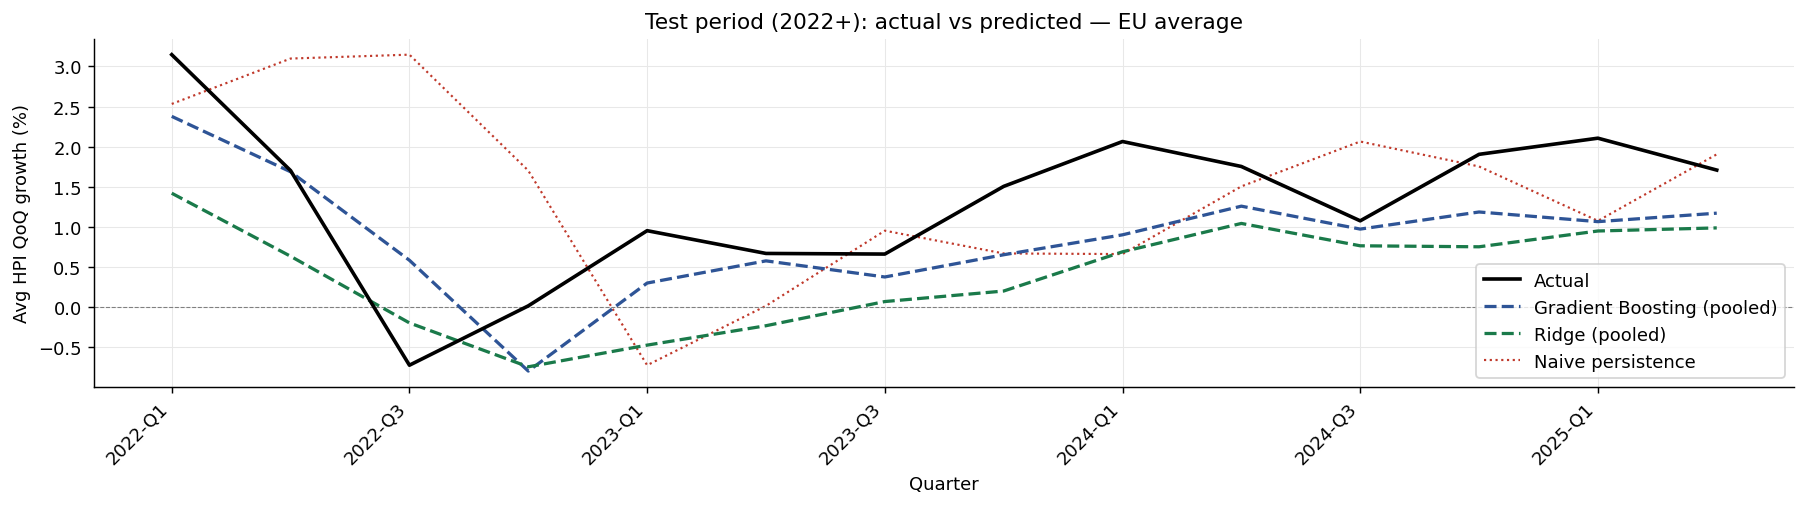

In [29]:

# Actual vs predicted over time: GB and Ridge pooled models
eu_actual = preds.groupby('quarter')['y_true'].mean()
eu_gb     = preds.groupby('quarter')['gb'].mean()
eu_ridge  = preds.groupby('quarter')['ridge'].mean()
eu_naive  = preds.groupby('quarter')['naive_persistence'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(eu_actual.index, eu_actual.values, color='black',
        linewidth=2, label='Actual', zorder=4)
ax.plot(eu_gb.index,    eu_gb.values,    color=ACCENT,
        linewidth=1.8, linestyle='--', label='Gradient Boosting (pooled)', zorder=3)
ax.plot(eu_ridge.index, eu_ridge.values, color=GREEN,
        linewidth=1.8, linestyle='--', label='Ridge (pooled)', zorder=3)
ax.plot(eu_naive.index, eu_naive.values, color=RED,
        linewidth=1.2, linestyle=':', label='Naive persistence', zorder=2)
ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
ax.set_xlabel('Quarter')
ax.set_ylabel('Avg HPI QoQ growth (%)')
ax.set_title('Test period (2022+): actual vs predicted — EU average')
ticks = eu_actual.index[::2]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Export Predictions

In [30]:
# Save all predictions for metrics.ipynb
#preds.to_csv('./predictions.csv', index=False)
preds.to_csv(r"C:\Users\Giulia\Documents\GitHub\european-house-market-forecasting\predictions.csv", index=False)

print('Saved: predictions.csv')
print(f'Shape: {preds.shape}')
print(f'\nColumns:')
for col in preds.columns:
    n_null = preds[col].isna().sum()
    note = f'  ({n_null} NaN: cluster not present for some rows)' if n_null > 0 else ''
    print(f'  {col}{note}')

print('\nReady for metrics.ipynb')
print('Load predictions.csv and compute RMSE / MAE / R2 across all model columns.')


Saved: predictions.csv
Shape: (364, 46)

Columns:
  country_code
  country
  quarter
  year
  cluster_data
  cluster_literature
  y_true
  naive_persistence
  rolling_mean
  ols
  ridge
  lasso
  rf
  gb
  ridge_km0  (308 NaN: cluster not present for some rows)
  lasso_km0  (308 NaN: cluster not present for some rows)
  ridge_km1  (336 NaN: cluster not present for some rows)
  lasso_km1  (336 NaN: cluster not present for some rows)
  ridge_km2  (238 NaN: cluster not present for some rows)
  lasso_km2  (238 NaN: cluster not present for some rows)
  rf_km2  (238 NaN: cluster not present for some rows)
  gb_km2  (238 NaN: cluster not present for some rows)
  ridge_km3  (210 NaN: cluster not present for some rows)
  lasso_km3  (210 NaN: cluster not present for some rows)
  rf_km3  (210 NaN: cluster not present for some rows)
  gb_km3  (210 NaN: cluster not present for some rows)
  ridge_lit_east  (196 NaN: cluster not present for some rows)
  lasso_lit_east  (196 NaN: cluster not present f

### Final Validation: Walk-Forward Cross-Validation Integrity Check
As a final robustness step, we validate the structure of the walk-forward cross-validation procedure. This ensures that all training folds strictly precede their corresponding validation folds in time and that no future information is mistakenly used during model estimation.

In [22]:
# Re-sort by time first before splitting
train_df_sorted = train_df.sort_values(['quarter', 'country_code']).reset_index(drop=True)

X_sorted = train_df_sorted[FEATURES].values
y_sorted = train_df_sorted[TARGET].values

tscv = TimeSeriesSplit(n_splits=5)

print("WALK-FORWARD CV FOLD BOUNDARIES")
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_sorted), 1):
    tr_quarters  = train_df_sorted.iloc[tr_idx]['quarter']
    val_quarters = train_df_sorted.iloc[val_idx]['quarter']
    print(f"Fold {fold}:")
    print(f"  Train: {tr_quarters.min()} -> {tr_quarters.max()}  ({len(tr_idx)} rows)")
    print(f"  Val:   {val_quarters.min()} -> {val_quarters.max()}  ({len(val_idx)} rows)")

WALK-FORWARD CV FOLD BOUNDARIES
Fold 1:
  Train: 2006-Q4 -> 2011-Q4  (204 rows)
  Val:   2011-Q4 -> 2014-Q1  (199 rows)
Fold 2:
  Train: 2006-Q4 -> 2014-Q1  (403 rows)
  Val:   2014-Q1 -> 2016-Q1  (199 rows)
Fold 3:
  Train: 2006-Q4 -> 2016-Q1  (602 rows)
  Val:   2016-Q1 -> 2018-Q1  (199 rows)
Fold 4:
  Train: 2006-Q4 -> 2018-Q1  (801 rows)
  Val:   2018-Q1 -> 2020-Q1  (199 rows)
Fold 5:
  Train: 2006-Q4 -> 2020-Q1  (1000 rows)
  Val:   2020-Q1 -> 2021-Q4  (199 rows)


In [23]:
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_sorted), 1):
    # check for overlap
    overlap = set(tr_idx) & set(val_idx)
    print(f"Fold {fold}: overlap={len(overlap)} rows")  # should always be 0

Fold 1: overlap=0 rows
Fold 2: overlap=0 rows
Fold 3: overlap=0 rows
Fold 4: overlap=0 rows
Fold 5: overlap=0 rows


## Walk-Forward Cross-Validation

To evaluate model performance without leaking future information into training, we use **walk-forward (expanding window) cross-validation** instead of standard k-fold CV.

In standard k-fold, data is split randomly and this is inappropriate for time series because a model could be trained on 2018 data and validated on 2015 data, which is impossible in a real forecasting setting and it doesnt make any sense.

Walk-forward CV **respects** the temporal order of the data:
- The training window always starts at the beginning (2006-Q4) and **expands** forward
- The validation window is always a future period the model has never seen
- At no point does the model train on data that comes after the validation period

With 5 folds across 1,200 training rows this gives us validation windows of roughly 200 rows (2 years of EU-wide data) each, which is large enough to produce stable RMSE estimates.

As we can see from the resulsts in the fold boundaries print the same quarter (e.g. `2011-Q4`) as both the last train quarter and the first val quarter. This is not data leakage: each quarter contains 26 rows (one per country), and `TimeSeriesSplit` splits on row indices, so no row ever appears in both train and validation. The shared quarter label is just a boundary artefact of how `min()` and `max()` are printed.

the validation window ends at 2021-Q4, meaning the CV never evaluates the 2022–2025 period. This is intentional: that period is reserved as the
**held-out test set** for final model comparison, ensuring it is never touched during any part of model selection or tuning.